## Step 1: Load Data and Initial Inspection

In this step, we load the raw Telco Customer Churn dataset and perform an initial inspection of its structure, including the number of rows, columns, and data types. This helps identify potential data quality issues, such as columns that should be numeric but are stored as text, before moving on to cleaning and database creation.

In [1]:
import pandas as pd
import sqlite3

# Load the raw dataset
df = pd.read_csv('telco_churn.csv')

# Quick check of shape and column types
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

## Step 2: Clean the TotalCharges Column

The TotalCharges column was loaded as an object (text) type instead of a numeric type. This is likely caused by blank or whitespace values for customers with zero tenure (new customers who have not yet been billed). In this step,I convert TotalCharges to a numeric type and inspect any rows that fail conversion.

In [2]:
# Try converting TotalCharges to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many rows became NaN after conversion
print(df['TotalCharges'].isnull().sum())

# Inspect those specific rows
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


## Step 3: Fill Missing TotalCharges Values

All 11 rows with missing TotalCharges correspond to customers with zero tenure, meaning they have not yet been billed. Since TotalCharges represents cumulative billing, it is mathematically correct to fill these missing values with 0 rather than using an imputation method like the mean.

In [3]:
# Fill missing TotalCharges with 0 for zero-tenure customers
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm no missing values remain
print(df['TotalCharges'].isnull().sum())
print(df['TotalCharges'].dtype)

0
float64


## Step 4: Inspect Unique Values in Categorical Columns

Before loading the data into SQLite, we check the unique values of each categorical column to ensure consistency (e.g., no unexpected typos, extra whitespace, or inconsistent labeling).

In [4]:
# Identify categorical (object-type) columns, excluding the ID
categorical_cols = df.select_dtypes(include='object').columns.drop('customerID')

# Print unique values for each categorical column
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


## Step 5: Create SQLite Database and Split into Relational Tables

To better demonstrate SQL skills (joins, relational queries), the cleaned dataset is split into three related tables instead of one flat table:

- **customers**: demographic information (customerID, gender, SeniorCitizen, Partner, Dependents, tenure)
- **services**: subscribed services (customerID, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies)
- **billing**: contract and payment details, including the churn label (customerID, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn)

All three tables share customerID as a common key, allowing them to be joined together in later analysis.

In [5]:
# Define column groups for each table
customer_cols = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']
service_cols = ['customerID', 'PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
billing_cols = ['customerID', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                'MonthlyCharges', 'TotalCharges', 'Churn']

customers_df = df[customer_cols]
services_df = df[service_cols]
billing_df = df[billing_cols]

# Create SQLite database and write each table
conn = sqlite3.connect('telco_churn.db')

customers_df.to_sql('customers', conn, index=False, if_exists='replace')
services_df.to_sql('services', conn, index=False, if_exists='replace')
billing_df.to_sql('billing', conn, index=False, if_exists='replace')

# Confirm tables were created
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

        name
0  customers
1   services
2    billing


## Step 6: Churn Rate by Contract Type

This query examines the relationship between contract type and customer churn. It joins the billing table (which contains both Contract and Churn) is sufficient on its own here, but we use a JOIN with customers to demonstrate relational querying and to later allow segmentation by tenure or demographics. We calculate the churn rate as a percentage for each contract type.

In [6]:
query = """
SELECT
    b.Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM billing b
JOIN customers c ON b.customerID = c.customerID
GROUP BY b.Contract
ORDER BY churn_rate_pct DESC;
"""

result = pd.read_sql(query, conn)
result

,Contract,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


## Step 7: Churn Rate by Payment Method

This query investigates whether payment method is associated with churn. Electronic check payments are often linked to higher churn in this dataset, possibly reflecting a less engaged or less stable customer segment compared to automatic payment methods.

In [7]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charge
FROM billing
GROUP BY PaymentMethod
ORDER BY churn_rate_pct DESC;
"""

result = pd.read_sql(query, conn)
result

,PaymentMethod,total_customers,churned_customers,churn_rate_pct,avg_monthly_charge
0,Electronic check,2365,1071,45.29,76.26
1,Mailed check,1612,308,19.11,43.92
2,Bank transfer (automatic),1544,258,16.71,67.19
3,Credit card (automatic),1522,232,15.24,66.51


## Step 8: Churn Rate by Tenure Cohort (Window Function)

This query groups customers into tenure-based cohorts (e.g., 0-12 months, 13-24 months) using a CASE statement, then calculates churn rate per cohort. This reveals whether churn risk is concentrated in the early stages of the customer lifecycle, a common pattern in subscription businesses.

In [8]:
query = """
SELECT
    CASE
        WHEN c.tenure <= 12 THEN '0-12 months'
        WHEN c.tenure <= 24 THEN '13-24 months'
        WHEN c.tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_cohort,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers c
JOIN billing b ON c.customerID = b.customerID
GROUP BY tenure_cohort
ORDER BY MIN(c.tenure);
"""

result = pd.read_sql(query, conn)
result

,tenure_cohort,total_customers,churned_customers,churn_rate_pct
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


## Step 9: Customer Value Quartiles Using NTILE Window Function

This query uses the NTILE window function to divide customers into four quartiles based on TotalCharges (a proxy for customer lifetime value), then calculates the churn rate within each quartile. This helps identify whether high-value or low-value customers are more likely to churn.

In [9]:
query = """
WITH customer_quartiles AS (
    SELECT
        customerID,
        TotalCharges,
        Churn,
        NTILE(4) OVER (ORDER BY TotalCharges) AS value_quartile
    FROM billing
)
SELECT
    value_quartile,
    COUNT(*) AS total_customers,
    ROUND(MIN(TotalCharges), 2) AS min_total_charges,
    ROUND(MAX(TotalCharges), 2) AS max_total_charges,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customer_quartiles
GROUP BY value_quartile
ORDER BY value_quartile;
"""

result = pd.read_sql(query, conn)
result

,value_quartile,total_customers,min_total_charges,max_total_charges,churned_customers,churn_rate_pct
0,1,1761,0.00,398.55,762,43.27
1,2,1761,398.55,1394.55,447,25.38
2,3,1761,1395.05,3789.20,405,23.00
3,4,1760,3791.60,8684.80,255,14.49


## Step 10: Churn Rate by Internet Service Type and Add-on Services

This query joins the billing and services tables to examine how internet service type and the presence of add-on services (such as OnlineSecurity and TechSupport) relate to churn. Customers without these protective services are often more likely to churn, possibly due to lower engagement or unresolved technical issues.

In [10]:
query = """
SELECT
    s.InternetService,
    s.TechSupport,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM services s
JOIN billing b ON s.customerID = b.customerID
WHERE s.InternetService != 'No'
GROUP BY s.InternetService, s.TechSupport
ORDER BY s.InternetService, churn_rate_pct DESC;
"""

result = pd.read_sql(query, conn)
result

,InternetService,TechSupport,total_customers,churned_customers,churn_rate_pct
0,DSL,No,1243,345,27.76
1,DSL,Yes,1178,114,9.68
2,Fiber optic,No,2230,1101,49.37
3,Fiber optic,Yes,866,196,22.63


## Step 11: High-Risk Customer Profile (Combining All Three Tables)

This final query joins all three tables (customers, services, billing) to build a complete profile of the highest-risk segment identified so far: month-to-month customers with Fiber optic internet, no tech support, and electronic check payment. We compare this segment against the overall customer base to quantify how much higher its churn risk is.

In [11]:
query = """
SELECT
    'High-Risk Segment' AS segment,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(c.tenure), 1) AS avg_tenure,
    ROUND(AVG(b.MonthlyCharges), 2) AS avg_monthly_charge
FROM customers c
JOIN services s ON c.customerID = s.customerID
JOIN billing b ON c.customerID = b.customerID
WHERE b.Contract = 'Month-to-month'
  AND s.InternetService = 'Fiber optic'
  AND s.TechSupport = 'No'
  AND b.PaymentMethod = 'Electronic check'

UNION ALL

SELECT
    'Overall Customer Base' AS segment,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(c.tenure), 1) AS avg_tenure,
    ROUND(AVG(b.MonthlyCharges), 2) AS avg_monthly_charge
FROM customers c
JOIN services s ON c.customerID = s.customerID
JOIN billing b ON c.customerID = b.customerID;
"""

result = pd.read_sql(query, conn)
result

,segment,total_customers,churned_customers,churn_rate_pct,avg_tenure,avg_monthly_charge
0,High-Risk Segment,1138,716,62.92,18.1,85.91
1,Overall Customer Base,7043,1869,26.54,32.4,64.76


## Step 12: Business KPI Summary

This query calculates the key business metrics for the Telco churn analysis in a single view. These KPIs provide a high-level snapshot of the business health and are designed to be used as summary cards in the Power BI dashboard.

| KPI | Description |
|-----|-------------|
| overall_churn_rate_pct | Percentage of customers who churned |
| high_risk_customer_count | Customers matching the highest-risk profile |
| avg_tenure_churned | Average months a churned customer stayed |
| avg_tenure_retained | Average months a retained customer has stayed |
| monthly_revenue_lost | Total monthly charges lost due to churn |
| monthly_revenue_at_risk | Monthly charges from high-risk segment still active |
| avg_monthly_charge_churned | Average monthly charge of churned customers |

In [12]:
query = """
SELECT
    -- Overall churn rate
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2)
        AS overall_churn_rate_pct,

    -- High-risk customer count (still active)
    SUM(CASE WHEN b.Contract = 'Month-to-month'
                  AND s.InternetService = 'Fiber optic'
                  AND s.TechSupport = 'No'
                  AND b.PaymentMethod = 'Electronic check'
                  AND b.Churn = 'No' THEN 1 ELSE 0 END)
        AS high_risk_active_customers,

    -- Average tenure: churned vs retained
    ROUND(AVG(CASE WHEN b.Churn = 'Yes' THEN c.tenure END), 1)
        AS avg_tenure_churned,
    ROUND(AVG(CASE WHEN b.Churn = 'No' THEN c.tenure END), 1)
        AS avg_tenure_retained,

    -- Monthly revenue lost due to churn
    ROUND(SUM(CASE WHEN b.Churn = 'Yes' THEN b.MonthlyCharges ELSE 0 END), 2)
        AS monthly_revenue_lost,

    -- Monthly revenue at risk (high-risk segment, still active)
    ROUND(SUM(CASE WHEN b.Contract = 'Month-to-month'
                        AND s.InternetService = 'Fiber optic'
                        AND s.TechSupport = 'No'
                        AND b.PaymentMethod = 'Electronic check'
                        AND b.Churn = 'No'
                   THEN b.MonthlyCharges ELSE 0 END), 2)
        AS monthly_revenue_at_risk,

    -- Average monthly charge of churned customers
    ROUND(AVG(CASE WHEN b.Churn = 'Yes' THEN b.MonthlyCharges END), 2)
        AS avg_monthly_charge_churned

FROM customers c
JOIN services s ON c.customerID = s.customerID
JOIN billing b ON c.customerID = b.customerID;
"""

kpi = pd.read_sql(query, conn)
kpi.T.rename(columns={0: 'Value'})

,Value
overall_churn_rate_pct,26.54
high_risk_active_customers,422.00
avg_tenure_churned,18.00
avg_tenure_retained,37.60
monthly_revenue_lost,139130.85
monthly_revenue_at_risk,36409.60
avg_monthly_charge_churned,74.44


## Step 13: Export Query Results for Power BI

We export the key analysis results to CSV files so they can be imported into Power BI for dashboard creation. We export the cleaned full dataset, the KPI summary, and the segment-level churn breakdown.

In [13]:
# Export cleaned full dataset
df.to_csv('telco_churn_cleaned.csv', index=False)

# Export KPI summary
kpi.T.rename(columns={0: 'Value'}).to_csv('kpi_summary.csv')

# Export churn by contract type
query_contract = """
SELECT
    b.Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM billing b
JOIN customers c ON b.customerID = c.customerID
GROUP BY b.Contract
ORDER BY churn_rate_pct DESC;
"""
pd.read_sql(query_contract, conn).to_csv('churn_by_contract.csv', index=False)

# Export churn by tenure cohort
query_tenure = """
SELECT
    CASE
        WHEN c.tenure <= 12 THEN '0-12 months'
        WHEN c.tenure <= 24 THEN '13-24 months'
        WHEN c.tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END AS tenure_cohort,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers c
JOIN billing b ON c.customerID = b.customerID
GROUP BY tenure_cohort
ORDER BY MIN(c.tenure);
"""
pd.read_sql(query_tenure, conn).to_csv('churn_by_tenure.csv', index=False)

print("All files exported successfully.")
conn.close()

All files exported successfully.


## Step 14: Feature Engineering

Before training any model, we prepare the features from the cleaned dataset:
- Binary columns (Yes/No) are encoded as 1/0
- Multi-category columns (Contract, PaymentMethod, InternetService) are one-hot encoded
- A new feature `avg_monthly_spend_ratio` is created as MonthlyCharges divided by (tenure + 1), capturing how much a customer pays relative to how long they have been with the company
- The target variable (Churn) is encoded as 1 (Yes) and 0 (No)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reload cleaned data
df = pd.read_csv('telco_churn_cleaned.csv')

# Drop customerID (not a feature)
df = df.drop(columns=['customerID'])

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No phone service': 0,
                           'No internet service': 0})

# Encode gender and SeniorCitizen
df['gender'] = (df['gender'] == 'Male').astype(int)

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'],
                    drop_first=False)

# Create new feature: average monthly spend ratio
df['avg_monthly_spend_ratio'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train/test split (80/20, stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

Training set: (5634, 27)
Test set: (1409, 27)
Churn rate in train: 26.54%
Churn rate in test: 26.54%


## Step 15: Model Training and Comparison

We train and compare three classification models:
- **Logistic Regression**: a simple, interpretable baseline
- **Random Forest**: an ensemble method that handles non-linear relationships well
- **XGBoost**: a gradient boosting model known for strong performance on tabular data

All models are evaluated using ROC-AUC score, which is more informative than accuracy for imbalanced classification problems like churn prediction.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {'model': model, 'auc': auc, 'proba': y_pred_proba}
    print(f"{name}: AUC = {auc:.4f}")

Logistic Regression: AUC = 0.8467
Random Forest: AUC = 0.8207
XGBoost: AUC = 0.8212


## Step 16: Detailed Evaluation of the Best Model (Logistic Regression)

Logistic Regression achieved the highest AUC (0.8467), outperforming both ensemble methods. This suggests the relationships in this dataset are largely linear. We now examine the confusion matrix and classification report to understand precision, recall, and F1-score across both classes.

              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



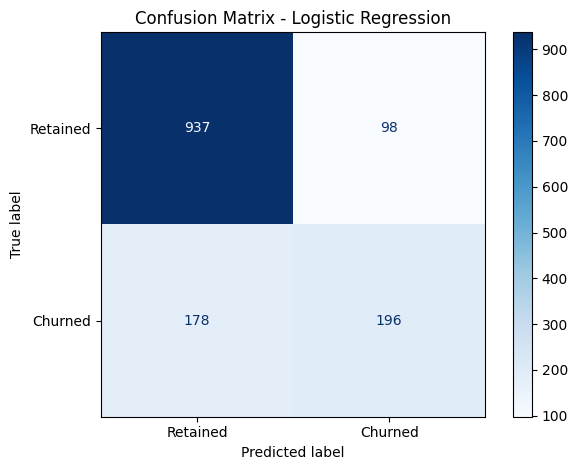

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best model: Logistic Regression
best_model = results['Logistic Regression']['model']
y_pred = best_model.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Step 17: Feature Importance (Logistic Regression Coefficients)

We examine the most influential features in the Logistic Regression model using its coefficients. Larger positive coefficients indicate features that increase churn probability, while negative coefficients indicate features associated with retention. This provides actionable business insights alongside the model results.

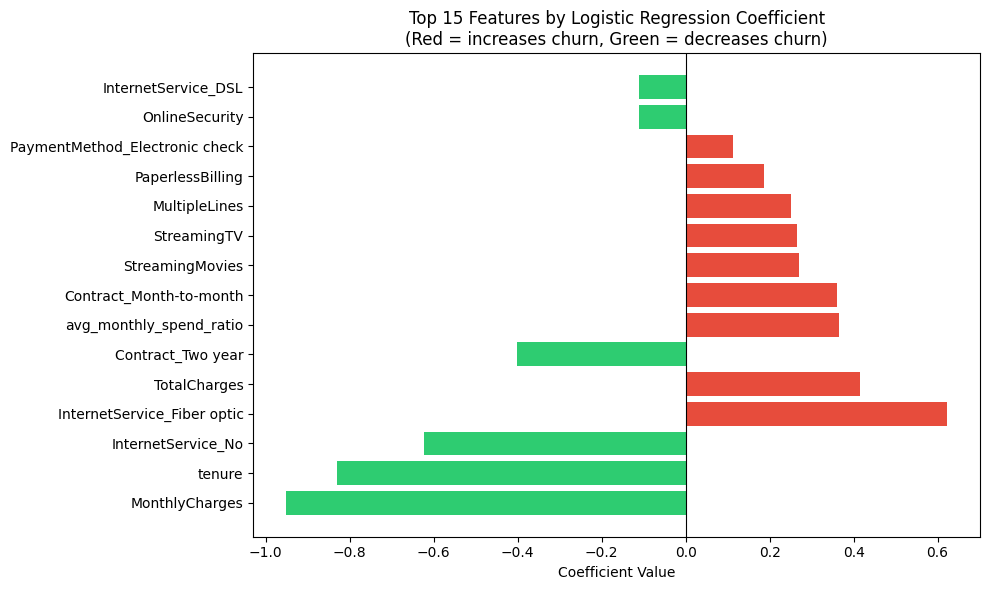

,feature,coefficient
14,MonthlyCharges,-0.950794
4,tenure,-0.830460
18,InternetService_No,-0.623871
17,InternetService_Fiber optic,0.622277
15,TotalCharges,0.415560
21,Contract_Two year,-0.401687
26,avg_monthly_spend_ratio,0.366117
19,Contract_Month-to-month,0.360221
12,StreamingMovies,0.271106
11,StreamingTV,0.264741


In [17]:
import numpy as np

# Extract feature importance from Logistic Regression coefficients
feature_names = X.columns.tolist()
coefficients = best_model.coef_[0]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False).head(15)

# Plot
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in importance_df['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 15 Features by Logistic Regression Coefficient\n(Red = increases churn, Green = decreases churn)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

importance_df

In [18]:
# Save feature importance data for Power BI
importance_df.to_csv('feature_importance.csv', index=False)

# Save model predictions with actual values for Power BI
predictions_df = X_test.copy()
predictions_df['actual_churn'] = y_test.values
predictions_df['predicted_churn'] = y_pred
predictions_df['churn_probability'] = results['Logistic Regression']['proba']
predictions_df.to_csv('model_predictions.csv', index=False)

print("Files saved:")
print("- feature_importance.csv")
print("- model_predictions.csv")
print("- confusion_matrix.png")
print("- feature_importance.png")

Files saved:
- feature_importance.csv
- model_predictions.csv
- confusion_matrix.png
- feature_importance.png


In [19]:
import sqlite3
import pandas as pd

# Reconnect to database
conn = sqlite3.connect('telco_churn.db')

query = """
SELECT
    ROUND(100.0 * SUM(CASE WHEN b.Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2)
        AS overall_churn_rate_pct,
    SUM(CASE WHEN b.Contract = 'Month-to-month'
                  AND s.InternetService = 'Fiber optic'
                  AND s.TechSupport = 'No'
                  AND b.PaymentMethod = 'Electronic check'
                  AND b.Churn = 'No' THEN 1 ELSE 0 END)
        AS high_risk_active_customers,
    ROUND(AVG(CASE WHEN b.Churn = 'Yes' THEN c.tenure END), 1)
        AS avg_tenure_churned,
    ROUND(AVG(CASE WHEN b.Churn = 'No' THEN c.tenure END), 1)
        AS avg_tenure_retained,
    ROUND(SUM(CASE WHEN b.Churn = 'Yes' THEN b.MonthlyCharges ELSE 0 END), 2)
        AS monthly_revenue_lost,
    ROUND(SUM(CASE WHEN b.Contract = 'Month-to-month'
                        AND s.InternetService = 'Fiber optic'
                        AND s.TechSupport = 'No'
                        AND b.PaymentMethod = 'Electronic check'
                        AND b.Churn = 'No'
                   THEN b.MonthlyCharges ELSE 0 END), 2)
        AS monthly_revenue_at_risk,
    ROUND(AVG(CASE WHEN b.Churn = 'Yes' THEN b.MonthlyCharges END), 2)
        AS avg_monthly_charge_churned
FROM customers c
JOIN services s ON c.customerID = s.customerID
JOIN billing b ON c.customerID = b.customerID;
"""

# Save as proper flat format (one row, each KPI as a column)
kpi = pd.read_sql(query, conn)
kpi.to_csv('kpi_summary.csv', index=False)
conn.close()

print(kpi)

   overall_churn_rate_pct  high_risk_active_customers  avg_tenure_churned  \
0                   26.54                         422                18.0   

   avg_tenure_retained  monthly_revenue_lost  monthly_revenue_at_risk  \
0                 37.6             139130.85                  36409.6   

   avg_monthly_charge_churned  
0                       74.44  


In [20]:
cohort_order = {
    '0-12 months': 1,
    '13-24 months': 2,
    '25-48 months': 3,
    '49+ months': 4
}

df_tenure = pd.read_csv('churn_by_tenure.csv')
df_tenure['sort_order'] = df_tenure['tenure_cohort'].map(cohort_order)
df_tenure = df_tenure.sort_values('sort_order')
df_tenure.to_csv('churn_by_tenure.csv', index=False)
print(df_tenure)

  tenure_cohort  total_customers  churned_customers  churn_rate_pct  \
0   0-12 months             2186               1037           47.44   
1  13-24 months             1024                294           28.71   
2  25-48 months             1594                325           20.39   
3    49+ months             2239                213            9.51   

   sort_order  
0           1  
1           2  
2           3  
3           4  
